# ANN Project — Credit Risk Classification

Build an Artificial Neural Network for credit-risk classification using the German Credit dataset. It covers multiclass classification, feature engineering, class imbalance, Batch Normalization, Dropout, early stopping, and hyperparameter experiments.

#### 1. Task Setup and Imports

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import Sequential, layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "statlog+german+credit+data/german.data"  


#### 2. Load and Inspect dataset


In [34]:
# Load the dataset
df = pd.read_csv(DATA_PATH, sep = r"\s+", header = None)

print("Shape:", df.shape)


Shape: (1000, 21)


In [35]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [36]:
columns = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "risk"
]

df.columns = columns

In [37]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [38]:
df['risk'].value_counts()

risk
1    700
2    300
Name: count, dtype: int64

- As per the documentation of the datatset, we can see that 1 is Good (700 customers) and 2 is bad(300 customers).


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account         1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment               1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [40]:
numerical_columns = df.select_dtypes(include = ['int64']).columns.tolist()
numerical_columns


['duration',
 'credit_amount',
 'installment_rate',
 'residence_since',
 'age',
 'existing_credits',
 'num_dependents',
 'risk']

In [41]:
categorical_columns = df.select_dtypes(include = ['str']).columns.tolist()
categorical_columns

['checking_account',
 'credit_history',
 'purpose',
 'savings_account',
 'employment',
 'personal_status_sex',
 'other_debtors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

#### 3. Clean the data

In [42]:
df.isnull().sum()

checking_account           0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment                 0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
risk                       0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

- There are no duplicates or null values.

In [44]:
print('Numerical_Columns', len(numerical_columns))
print('Categorical Columns', len(categorical_columns))

Numerical_Columns 8
Categorical Columns 13


#### 4. Prepare the Target variable

In [45]:
df['risk'] = df['risk'].map({
    1 : 0, 2 : 1
})

In [46]:
df['risk'].value_counts()

risk
0    700
1    300
Name: count, dtype: int64

#### 5. Feature Engineering

In [47]:
df['credit_per_month'] = df['credit_amount']/df['duration']
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,risk,credit_per_month
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,67,A143,A152,2,A173,1,A192,A201,0,194.833333
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,22,A143,A152,1,A173,1,A191,A201,1,123.979167
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,49,A143,A152,1,A172,2,A191,A201,0,174.666667
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,45,A143,A153,1,A173,2,A191,A201,0,187.666667
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,53,A143,A153,2,A173,2,A191,A201,1,202.916667


#### 6. Separate Features and Target

In [48]:
X = df.drop(columns = ['risk'])
y = df['risk']

In [49]:
print(X.shape)
print(y.shape)

(1000, 21)
(1000,)


#### 7. Encode categorical features

In [50]:
X = pd.get_dummies(X, columns = categorical_columns, drop_first = True)
X.head()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,credit_per_month,checking_account_A12,checking_account_A13,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,194.833333,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,123.979167,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,174.666667,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,187.666667,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,202.916667,False,False,...,True,False,True,False,True,False,True,False,False,False


In [51]:
X.shape

(1000, 49)

In [52]:
X = X.astype(int)

In [53]:
X.head()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,credit_per_month,checking_account_A12,checking_account_A13,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,194,0,0,...,0,0,1,1,0,0,1,0,1,0
1,48,5951,2,2,22,1,1,123,1,0,...,0,0,1,1,0,0,1,0,0,0
2,12,2096,2,3,49,1,2,174,0,0,...,0,0,1,1,0,1,0,0,0,0
3,42,7882,2,4,45,1,2,187,0,0,...,0,0,1,0,1,0,1,0,0,0
4,24,4870,3,4,53,2,2,202,0,0,...,1,0,1,0,1,0,1,0,0,0


#### 8. Train / Validate / Test Split

In [54]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.3, random_state = SEED, stratify = y
)

In [55]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = SEED, stratify = y_temp
)

#### 9. Statndardize Features

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

#### 10. Check class imbalance

Training class distribution:
risk
0    490
1    210
Name: count, dtype: int64


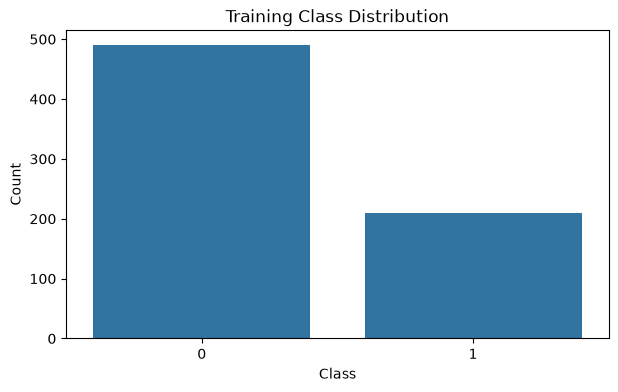

In [57]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

plt.figure(figsize=(7,4))
sns.countplot(x=y_train)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [58]:
# Copmute class weights to give more attention to the minority class
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.7142857142857143), np.int64(1): np.float64(1.6666666666666667)}


#### 11. Build the ANN

In [59]:
model = Sequential([
    layers.Input(shape = (X_train_scaled.shape[1],)),
    layers.Dense(128, activation = 'relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation = 'relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(32, activation = 'relu'),
    layers.Dense(1, activation = 'sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,153 (67.00 KB)

 Non-trainable params: 384 (1.50 KB)

#### 12. Compile the ANN

In [60]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

#### 13. Train with early stopping

In [61]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True

)

history = model.fit(
    X_train_scaled, 
    y_train,
    validation_data = [X_val_scaled, y_val],
    epochs = 30,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stop],
    verbose =1
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4314 - loss: 0.7930 - val_accuracy: 0.5133 - val_loss: 0.6934
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5843 - loss: 0.6515 - val_accuracy: 0.6267 - val_loss: 0.6416
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6729 - loss: 0.6023 - val_accuracy: 0.6933 - val_loss: 0.6169
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7043 - loss: 0.5495 - val_accuracy: 0.7133 - val_loss: 0.5998
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7171 - loss: 0.5212 - val_accuracy: 0.6867 - val_loss: 0.5849
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7529 - loss: 0.4877 - val_accuracy: 0.7000 - val_loss: 0.5694
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7486 - loss: 0.4546 - val_accuracy: 0.6933 - val_loss: 0.5552
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7771 - loss: 0.4412 - val_accuracy: 0.6867 - val_loss:

#### 14. Plot Training curves

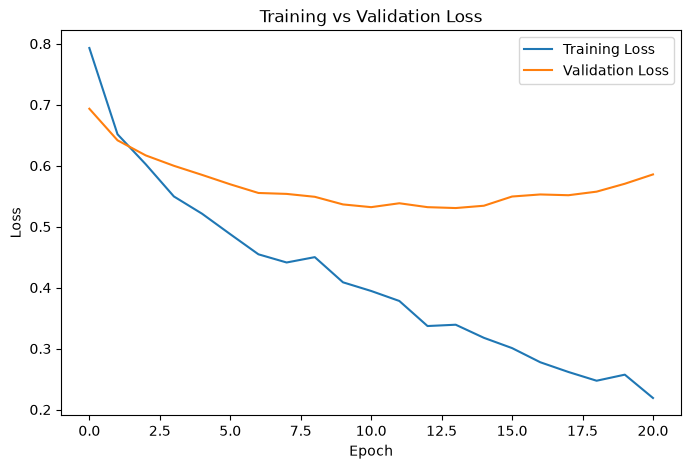

In [62]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


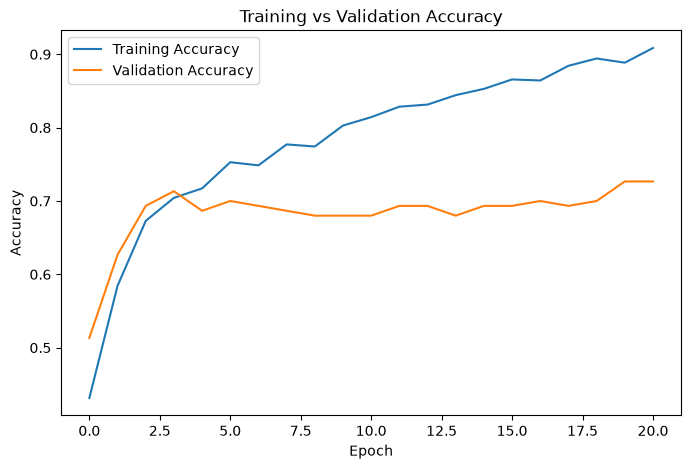

In [63]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

#### 15. Test Evaluation

In [64]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

# TODO: Predict class probabilities and classes
probabilities = model.predict(X_test_scaled, verbose=0)
predictions = (probabilities >=0.5).astype(int).flatten()

print(classification_report(y_test, predictions))


Test loss: 0.4855358898639679
Test accuracy: 0.7666666507720947
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       105
           1       0.60      0.69      0.64        45

    accuracy                           0.77       150
   macro avg       0.73      0.74      0.73       150
weighted avg       0.78      0.77      0.77       150



#### 16. Confusion Matrix

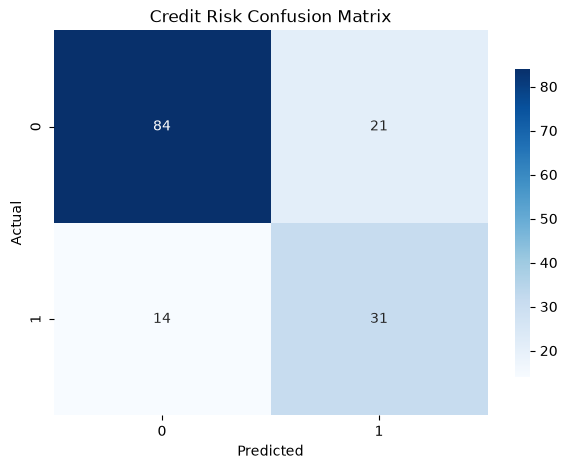

In [65]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={"shrink": 0.8})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Credit Risk Confusion Matrix")
plt.show()


#### 17. Precision and Recall per class

In [66]:
precision = precision_score(y_test, predictions, average=None, zero_division=0)
recall = recall_score(y_test, predictions, average=None, zero_division=0)
f1 = f1_score(y_test, predictions, average=None, zero_division=0)

for i in range(2):
    print(f"Class {i}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}")

Class 0: Precision=0.857, Recall=0.800, F1=0.828
Class 1: Precision=0.596, Recall=0.689, F1=0.639


#### 18, Hyperparameter Experiment